In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf
import os

In [2]:
df = pd.read_csv('final_w_features.csv')
df['date'] = pd.to_datetime(df['date'])
plotting_cols = ['discharge', 'precipitation', 'gage_height', 'DSCI']
df.tail()

,date,discharge,precipitation,gage_height,DSCI,severe_drought_pct,gage_height_lag1,gage_height_lag2,gage_height_lag3,gage_height_lag7,...,gage_height_diff1,gage_height_diff3,discharge_diff1,discharge_diff3,month,day_of_year,season,gage_height_t1,gage_height_t3,gage_height_t7
6226,2024-12-12,1050.0,0.00,4.133194,200.0,0.0,3.083542,2.989583,2.952639,2.905035,...,1.049653,1.180556,597.0,822.0,12,347,0,3.741701,3.249306,3.338403
6227,2024-12-13,652.0,0.00,3.741701,200.0,0.0,4.133194,3.083542,2.989583,2.931840,...,-0.391493,0.752118,-398.0,407.0,12,348,0,3.392396,3.313993,3.271840
6228,2024-12-14,459.0,0.00,3.392396,200.0,0.0,3.741701,4.133194,3.083542,2.924201,...,-0.349306,0.308854,-193.0,6.0,12,349,0,3.249306,3.484375,3.220764
6229,2024-12-15,382.0,9.20,3.249306,200.0,0.0,3.392396,3.741701,4.133194,2.918021,...,-0.143090,-0.883889,-77.0,-668.0,12,350,0,3.313993,3.412326,3.177917
6230,2024-12-16,474.0,1.62,3.313993,200.0,0.0,3.249306,3.392396,3.741701,2.952639,...,0.064688,-0.427708,92.0,-178.0,12,351,0,3.484375,3.338403,3.121806


In [5]:
df = pd.read_csv('merged_with_gage.csv', index_col='Unnamed: 0')
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,discharge,precipitation,gage_height,flood_risk
0,2007-10-01,37.9,0.0,2.151711,0
1,2007-10-02,37.1,0.0,2.146250,0
2,2007-10-03,36.4,0.0,2.140521,0
3,2007-10-04,37.6,0.0,2.150000,0
4,2007-10-05,38.1,0.0,2.150937,0


50th percentile: 3.16 ft
75th percentile: 3.73 ft
85th percentile: 4.13 ft
90th percentile: 4.50 ft
95th percentile: 5.38 ft
98th percentile: 7.36 ft
99th percentile: 9.59 ft
99.5th percentile: 12.09 ft


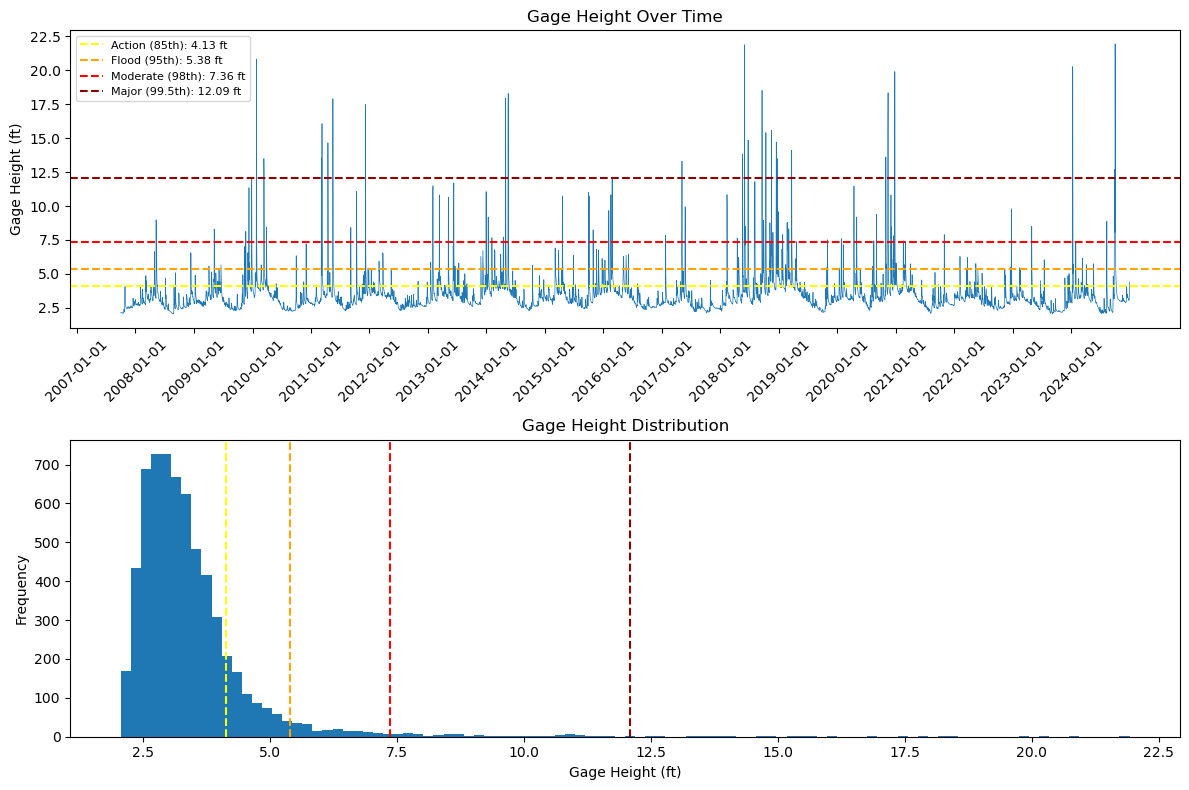

In [18]:
gage = df['gage_height'].dropna()

# Calculate a range of percentiles to help pick thresholds
percentiles = [50, 75, 85, 90, 95, 98, 99, 99.5]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(gage, p):.2f} ft")

# Plot the distribution with candidate thresholds
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Full time series
axes[0].plot(df['date'], df['gage_height'], linewidth=0.5)
axes[0].set_title('Gage Height Over Time')
axes[0].set_ylabel('Gage Height (ft)')
years = sorted(set(df.date.dt.year))
# Create datetime objects for Jan 1 of every year
years = [year for year in years]
jan1_ticks = [datetime(year, 1, 1) for year in years]

# Set the ticks
axes[0].set_xticks(jan1_ticks)
axes[0].tick_params('x', rotation=45)

# Histogram
axes[1].hist(gage, bins=100, edgecolor='none')
axes[1].set_title('Gage Height Distribution')
axes[1].set_xlabel('Gage Height (ft)')
axes[1].set_ylabel('Frequency')

# Add candidate threshold lines to both plots
thresholds = {
    'Action (85th)':   np.percentile(gage, 85),
    'Flood (95th)':    np.percentile(gage, 95),
    'Moderate (98th)': np.percentile(gage, 98),
    'Major (99.5th)':  np.percentile(gage, 99.5),
}
colors = ['yellow', 'orange', 'red', 'darkred']
for (label, value), color in zip(thresholds.items(), colors):
    axes[0].axhline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label}: {value:.2f} ft')
    axes[1].axvline(value, color=color, linestyle='--', linewidth=1.5, label=f'{label}: {value:.2f} ft')

axes[0].legend(fontsize=8)
#fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('gage_height_distribution.png', dpi=150)
plt.show()

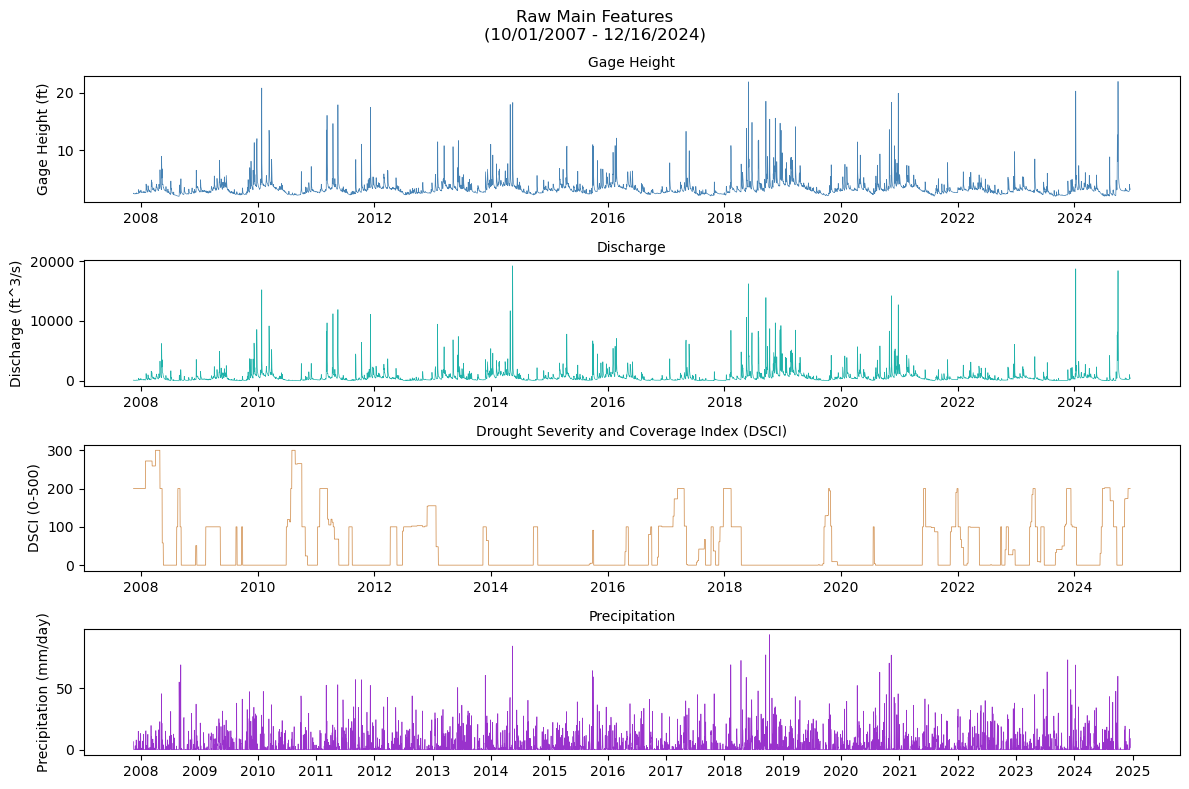

In [38]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=False)

# GAGE HEIGHT
axes[0].plot(df['date'], df['gage_height'], linewidth=0.5, color='steelblue', label='Gage Height')
axes[0].set_title('Gage Height', fontsize=10)
axes[0].set_ylabel('Gage Height (ft)')
axes[0] = plt.gca()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())


# DISCHARGE
axes[1].plot(df['date'], df['discharge'], linewidth=0.5, color='lightseagreen', label='Discharge')
axes[1].set_title('Discharge', fontsize=10)
axes[1].set_ylabel('Discharge (ft^3/s)')
axes[1] = plt.gca()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator())

# DSCI
axes[2].plot(df['date'], df['DSCI'], linewidth=0.5, color='peru', label='DSCI')
axes[2].set_title('Drought Severity and Coverage Index (DSCI)', fontsize=10)
axes[2].set_ylabel('DSCI (0-500)')
axes[2] = plt.gca()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator())

# Precipitation
axes[3].plot(df['date'], df['precipitation'], linewidth=0.5, color='darkorchid', label='Precipitation')
axes[3].set_title('Precipitation', fontsize=10)
axes[3].set_ylabel('Precipitation (mm/day)')
# Set the ticks
axes[3] = plt.gca()
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[3].xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle('Raw Main Features\n(10/01/2007 - 12/16/2024)')

plt.tight_layout()
plt.savefig('main_series_plot.png', dpi=150)
plt.show()

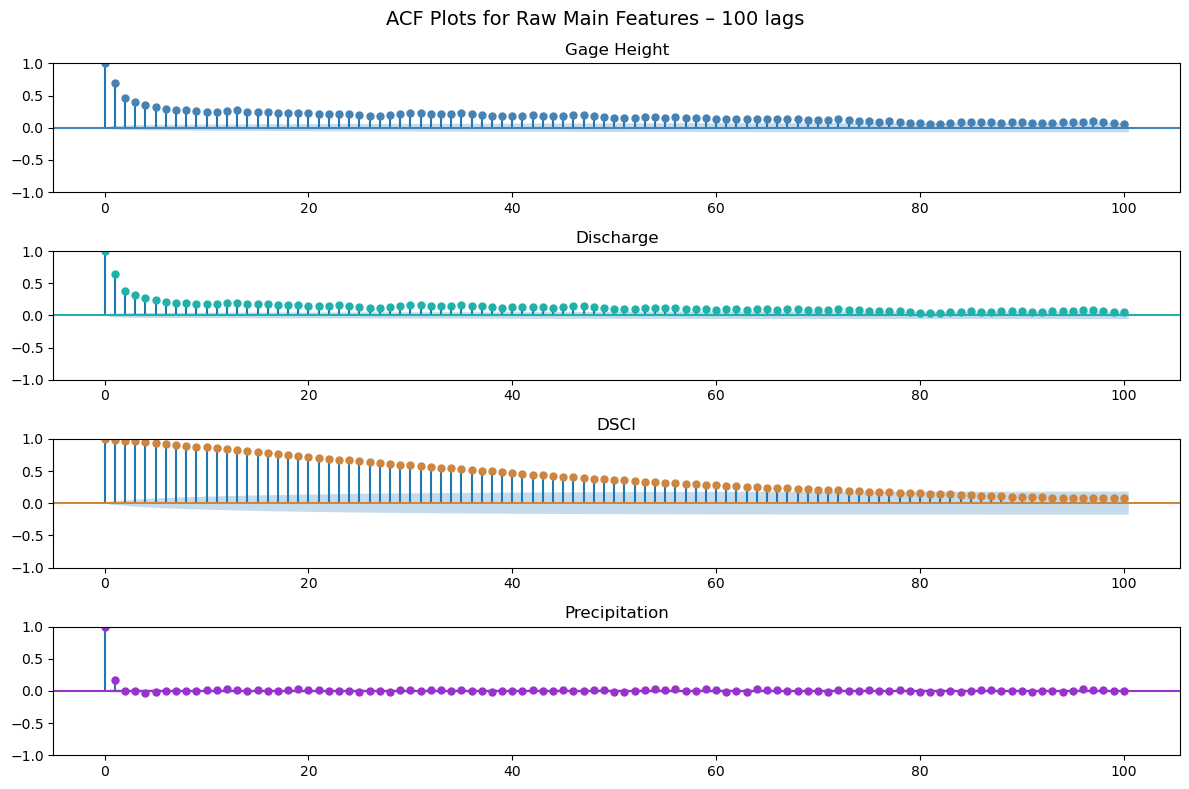

In [8]:
# Plot the distribution with candidate thresholds
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=False)

# GAGE HEIGHT
plot_acf(df['gage_height'], color='steelblue', lags=100, ax=axes[0], title='Gage Height')


# DISCHARGE
plot_acf(df['discharge'], color='lightseagreen', lags=100, ax=axes[1], title='Discharge')

# DSCI
plot_acf(df['DSCI'], color='peru', ax=axes[2], lags=100, title='DSCI')

# Precipitation
plot_acf(df['precipitation'], color='darkorchid', lags=100, ax=axes[3], title='Precipitation')

plt.suptitle('ACF Plots for Raw Main Features – 100 lags', fontsize=14)

plt.tight_layout()
#plt.savefig('main_series_plot.png', dpi=150)
plt.show()

<Axes: xlabel='gage_height', ylabel='Count'>

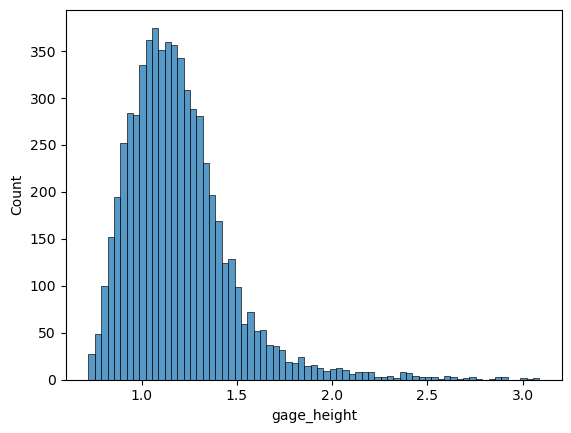

In [11]:
sns.histplot(np.log(df['gage_height']))

In [13]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

In [ ]:
precip_1 = df['precipitation'].shift(1).dropna()


In [14]:
pearsonr(df['precipitation'].shift(1), df['gage_height'])

PearsonRResult(statistic=np.float64(0.03425274304223111), pvalue=np.float64(0.006850020949792678))